In [9]:
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle  # 안정성을 위해 명시적 임포트
from matplotlib.lines import Line2D

In [10]:
# ------------------------------------------------------------------------------
# [환경 설정] 한글 깨짐 방지 및 출력 경로 설정
# ------------------------------------------------------------------------------
# 운영체제에 맞는 한글 폰트를 설정하세요 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

out_dir = "./" 
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 데이터 로드 (업로드해주신 파일명 반영 및 표준 한글 인코딩 대응)
try:
    df = pd.read_csv('C:/Users/User/Desktop/연구지점 데이터 정리/광산 지점.csv', encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv('C:/Users/User/Desktop/연구지점 데이터 정리/광산 지점.csv', encoding='euc-kr')

plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

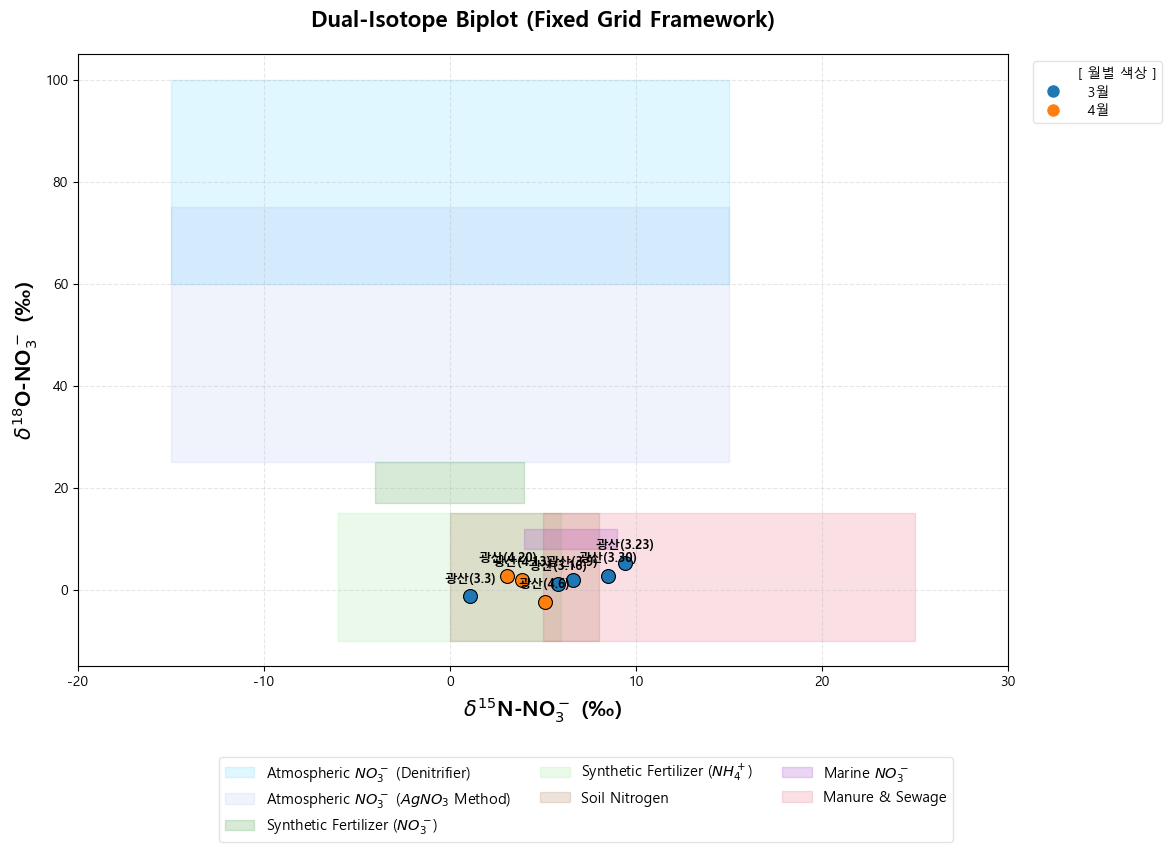

In [11]:
# ==============================================================================
# Dual-Isotope biplot (버전 1: 고정 축 범위)
# ==============================================================================
if not plot_df.empty:
    unique_months = sorted(plot_df['month'].unique())
    
    # 특정 지점 단독 분석이므로 마커 리스트 및 지점별 마커 매핑(marker_map) 제거
    color_map = {'3월': '#1f77b4', '4월': '#ff7f0e'} 

    fig, ax = plt.subplots(figsize=(12, 9))

    # 사각형 오염원 영역 패치 수집
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 데이터 scatter 플로팅 (월별로 그룹화하여 플로팅)
    for month, group in plot_df.groupby('month'):
        # 특정 지점 분석이므로 모든 마커를 기본 원형('o')으로 통일
        ax.scatter(group['d15N'], group['d18O'], 
                   color=color_map[month], 
                   marker='o', 
                   s=100, edgecolors='k', linewidths=0.8, zorder=4)
        
        # 각 데이터 포인트 위에 지점 라벨(날짜 정보 포함) 표시
        for _, row in group.iterrows():
            ax.annotate(row['spot'], (row['d15N'], row['d18O']),
                        textcoords="offset points", xytext=(0, 8), 
                        ha='center', va='bottom', fontsize=9, fontweight='semibold', zorder=5)

    # 축 라벨 및 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Fixed Grid Framework)", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # 우측 데이터 속성 범례: 지점별 표식을 제외하고 [ 월별 색상 ]만 깔끔하게 노출
    data_legend_elements = []
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 월별 색상 ]'))
    for m in unique_months:
        data_legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markersize=10, label=f'  {m}'))

    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
              fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.4)

    # 하단 오염원 영역 범례 (fig 레벨)
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    plt.subplots_adjust(bottom=0.2) 

    # 이미지 저장 및 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_biplot_fixed_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[경고] 데이터가 존재하지 않습니다.")

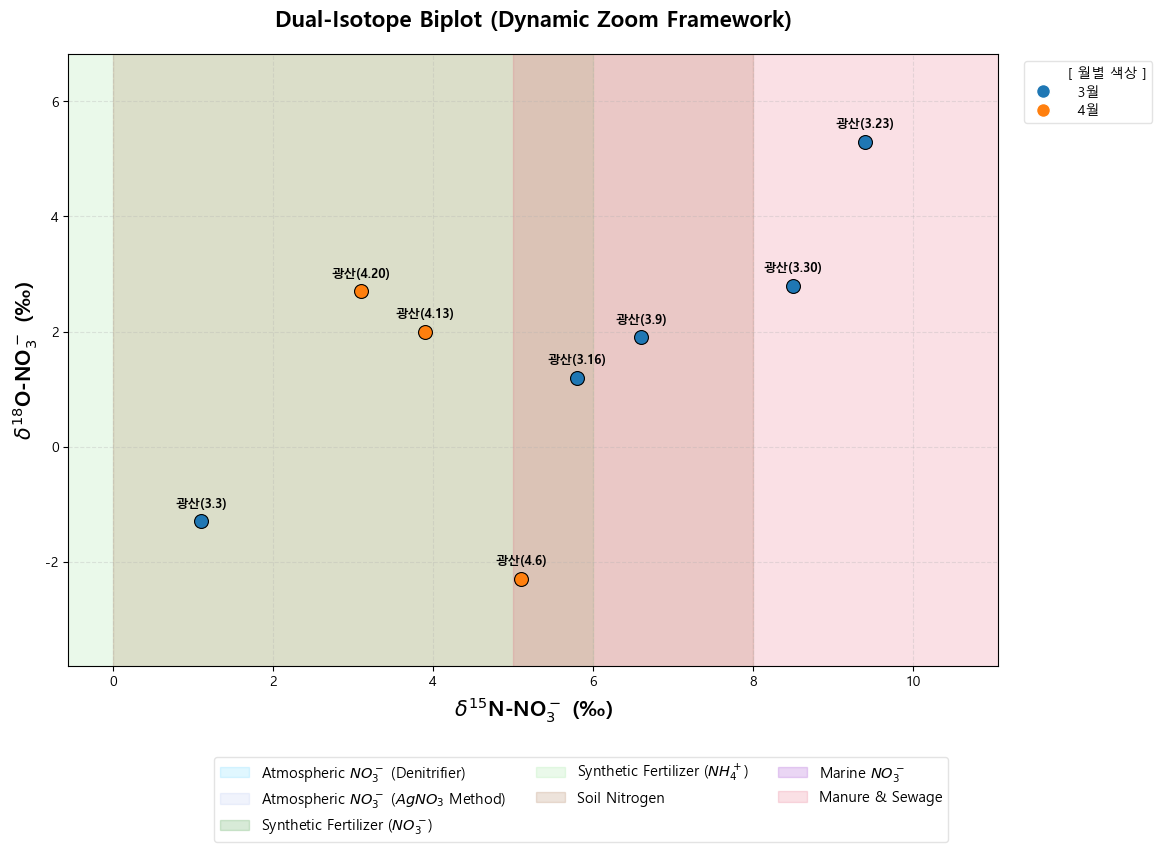

In [12]:
# ==============================================================================
# Dual-Isotope biplot (버전 2: 여백 기반 동적 축 범위 변형)
# ==============================================================================
if not plot_df.empty:
    unique_months = sorted(plot_df['month'].unique())
    
    color_map = {'3월': '#1f77b4', '4월': '#ff7f0e'} 

    fig, ax = plt.subplots(figsize=(12, 9))

    # 사각형 오염원 영역 패치 수집
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 데이터 scatter 플로팅 (월별로 그룹화하여 플로팅)
    for month, group in plot_df.groupby('month'):
        # 특정 지점 분석이므로 모든 마커를 기본 원형('o')으로 통일
        ax.scatter(group['d15N'], group['d18O'], 
                   color=color_map[month], 
                   marker='o', 
                   s=100, edgecolors='k', linewidths=0.8, zorder=4)
        
        # 각 데이터 포인트 위에 지점 라벨(날짜 정보 포함) 표시
        for _, row in group.iterrows():
            ax.annotate(row['spot'], (row['d15N'], row['d18O']),
                        textcoords="offset points", xytext=(0, 8), 
                        ha='center', va='bottom', fontsize=9, fontweight='semibold', zorder=5)

    # 축 라벨 및 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Dynamic Zoom Framework)", fontsize=16, fontweight='bold', pad=20)

    # 동적 스케일링 및 가독성을 위한 상하좌우 마진(20% 패딩) 부여
    x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
    y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()
    
    x_padding = (x_max - x_min) * 0.20 if x_max != x_min else 2.0
    y_padding = (y_max - y_min) * 0.20 if y_max != y_min else 2.0
    
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # 우측 데이터 속성 범례: 지점별 표식을 제외하고 [ 월별 색상 ]만 깔끔하게 노출
    data_legend_elements = []
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 월별 색상 ]'))
    for m in unique_months:
        data_legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markersize=10, label=f'  {m}'))

    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
              fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.4)

    # 하단 오염원 영역 범례 (fig 레벨)
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    plt.subplots_adjust(bottom=0.2) 

    # 이미지 저장 및 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_biplot_dynamic_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[경고] 데이터가 존재하지 않습니다.")